In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple, Dict, Any, Union
from openpyxl import load_workbook
from tqdm.notebook import tqdm
import matplotlib
from matplotlib import rc
rc("font", **{"family": "serif", "serif": ["Computer Modern"], "size":18})
rc("text", usetex=True)
np.random.seed(42)

In [4]:
df_train = pd.read_csv("/Users/jose/Documents/Works/MIT/AI/PyMassModels/Data/Experimental/be_exp.csv")
df_test = pd.read_csv("/Users/jose/Documents/Works/MIT/AI/PyMassModels/Data/Experimental/be_test.csv")


In [6]:
df_train

,Z,N,spinAndParity,betaMinus(keV),massExcess(keV),bindingEnergyLDMFit(keV),bindingEnergy(keV),bindingEnergyUncertainty,bindingEnergyLDMFitUncertainty,halflife,...,K,np,nn,T,BEpA,BE,semf,error_semf,dz,error_dz
0,9,18,(5/2+),18080.0,25130.0,-286.0,6880.0,4,4,1,...,3.000000,8,20,4.5,6.880,185.760,175.164000,10.596000,1.854679e+02,2.921415e-01
1,9,18,(5/2+),18080.0,25130.0,-286.0,6880.0,4,4,1,...,3.000000,8,20,4.5,6.880,185.760,175.164000,10.596000,1.854679e+02,2.921415e-01
2,9,18,(5/2+),18080.0,25130.0,-286.0,6880.0,4,4,1,...,3.000000,8,20,4.5,6.880,185.760,175.164000,10.596000,1.854679e+02,2.921415e-01
3,9,18,(5/2+),18080.0,25130.0,-286.0,6880.0,4,4,1,...,3.000000,8,20,4.5,6.880,185.760,175.164000,10.596000,1.854679e+02,2.921415e-01
4,9,16,5/2+,13370.0,11330.0,-208.0,7336.0,4,4,1,...,2.924018,8,20,3.5,7.336,183.400,175.483912,7.916088,1.820203e+02,1.379673e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4747,110,162,0+,-6700.0,136100.0,2.5,7255.0,20,20,1,...,6.479224,126,184,26.0,7.255,1973.360,1978.173440,-4.813440,3.175834e+06,-3.173860e+06
4748,112,166,0+,-6200.0,152800.0,9.3,7206.0,20,20,1,...,6.526519,126,184,27.0,7.206,2003.268,2010.214781,-6.946781,3.363349e+06,-3.361346e+06
4749,112,168,0+,-5600.0,155700.0,13.4,7202.0,20,20,1,...,6.542133,126,184,28.0,7.202,2016.560,2024.833697,-8.273697,3.443667e+06,-3.441651e+06
4750,114,174,0+,-4700.0,174900.0,17.0,7154.0,3,3,1,...,6.603854,126,184,30.0,7.154,2060.352,2070.242968,-9.890968,3.691562e+06,-3.689502e+06


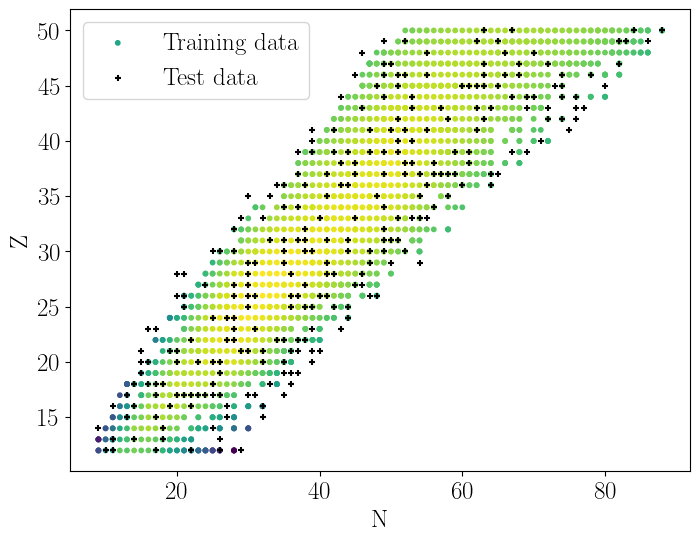

In [29]:
# Scatter N vs Z
# Paint the training data by E
# Test data as black
fig, ax = plt.subplots(figsize=(8, 6))
train = df_train.query("Z >= 12").query("Z<=50")
test = df_test.query("Z >= 12").query("Z<=50")
plt.scatter(train["N"], train["Z"], c=train["BE"]/train["A"], cmap="viridis", s=10, label="Training data")
plt.scatter(test["N"], test["Z"], c="black", s=20, label="Test data", marker="+")
ax.set_xlabel("N")
ax.set_ylabel("Z")
# Label the colorbar
plt.legend()

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import imageio

# Define the number of frames (iterations) for the GIF
n_frames = 10

# Generate sample data (x and y)
np.random.seed(42)
x = np.linspace(-6, 6, 200)
y_true = np.sin(x)  # True underlying function
y_observed = y_true + np.random.normal(0, 0.5, size=x.shape)  # Add some noise

# Set up storage for GIF frames
filenames = []

In [49]:
# Let's modify the GIF generation process to include MISR notation on each frame.
# We will add the corresponding expansion terms to each frame to show the progression in MISR notation.

# Define the terms of the expansion in a list (these are just placeholders for illustration)
expansion_terms = [
    r"$0$",
    r"$f_1$",
    r"$f_2$",
    r"$f_3$",
    r"$f_4$",
    r"$f_4 + f_5$",
    r"$f_4 + f_5 + f_6$",
    r"$f_4 + f_5 + f_6 + f_7$",
    r"$f_4 + f_5 + f_6 + f_7 + f_8$",
    r"$f_4 + f_5 + f_6 + f_7 + f_8 + f_9$"
    r"$f_4 + f_5 + f_6 + f_7 + f_8 + f_9 + f_{10}$"
]
# Set up storage for the new GIF frames with MISR notation
filenames_misr = []

# Initial predictions start at zero
y_pred = np.zeros_like(x)

# Simulate the Boosted Regression process and add the corresponding MISR term notation
for i in range(n_frames):
    i +=1
    plt.figure(figsize=(10, 8))

    # Calculate residuals between true values and current prediction
    residuals = y_true - y_pred

    # Add a portion of the residuals to the prediction (simulating boosting behavior)
    y_pred += 0.2 * residuals  # Gradually improve the model's fit

    # Bottom plot: observed data vs. fit vector
    plt.scatter(x, y_observed, edgecolor='black', facecolor='none', label='Observed Data')
    plt.plot(x, y_pred, 'r--', label='MISR central estimation Prediction', linewidth=2)  # Dashed line for the model prediction
    plt.plot(x, y_true, 'b-', label='True Function', linewidth=2)  # True underlying function

    # Add lines connecting observed points to the prediction to visualize the residuals
    for xi, yi_obs, yi_pred in zip(x, y_observed, y_pred):
        plt.plot([xi, xi], [yi_obs, yi_pred], color='red' if yi_obs > yi_pred else 'blue', alpha=0.4)

    # Titles, labels, and MISR term annotation
    # plt.title(f'Boosted Regression Model Fitting (Iteration {i+1})')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()

    # Add the MISR expansion term notation to the plot as title
    k = i-1
    misr_text = fr"$MISR(X)_{{{i}}}$ = $MISR(X)_{{{k}}}$ + " + f"f_{i}"
    plt.title(misr_text)

    # Save current frame
    filename = f'frame_misr_{i}.png'
    filenames_misr.append(filename)
    plt.savefig(filename)
    plt.close()

# Generate the new GIF with MISR expansion terms
with imageio.get_writer('./boosted_regression_misr.gif', mode='I', duration=0.2) as writer:
    for filename in filenames_misr:
        image = imageio.imread(filename)
        writer.append_data(image)


/var/folders/zg/s97g7gnj27z83xl9nrhntgxm0000gn/T/ipykernel_91850/3426439965.py:64: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(filename)
